In [4]:
!pip install ultralytics
from ultralytics import YOLO
import os

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [19]:
models_paths = {
    "YOLOv5": "/content/Ewolucja_YOLO/YOLOv5s/best.pt",
    "YOLOv8": "/content/Ewolucja_YOLO/YOLOv8s/best.pt",
    "YOLO11": "/content/Ewolucja_YOLO/YOLO11s/best.pt"
}

In [6]:
!pwd

/content


In [7]:
!ls

sample_data  test.jpg


In [9]:
test_image_path = "/content/test.jpg"

In [20]:
if not os.path.exists(test_image_path):
    print(f"Błąd: Nie znaleziono zdjęcia pod ścieżką: {test_image_path}")
else:
    # 4. Pętla przechodząca przez każdy model
    for model_name, file_path in models_paths.items():
        if os.path.exists(file_path):
            print(f"\n[INFO] Ładowanie i uruchamianie modelu: {model_name} ({file_path})...")

            # Ładowanie wag modelu
            model = YOLO(file_path)

            # Wykonanie predykcji (detekcji)
            # save=True -> automatycznie rysuje ramki i zapisuje gotowy obrazek na dysku
            # conf=0.25 -> próg pewności (pokazuje wykryte ubrania, których pewność wynosi min. 25%)
            # project i name -> foldery, w których zapiszą się wyniki (np. Wyniki_Testow/YOLO11s)
            model.predict(
                source=test_image_path,
                save=True,
                conf=0.25,
                project="Wyniki_Testow",
                name=model_name
            )
            print(f"[SUKCES] Wynik dla {model_name} został zapisany w folderze 'Wyniki_Testow/{model_name}'")
        else:
            print(f"Błąd: Nie znaleziono pliku modelu: {file_path}")


[INFO] Ładowanie i uruchamianie modelu: YOLOv5 (/content/Ewolucja_YOLO/YOLOv5s/best.pt)...

image 1/1 /content/test.jpg: 640x480 1 shirt, 1 pants, 1 bag, 1 shoe, 12.9ms
Speed: 1.8ms preprocess, 12.9ms inference, 4.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/Wyniki_Testow/YOLOv5
[SUKCES] Wynik dla YOLOv5 został zapisany w folderze 'Wyniki_Testow/YOLOv5'

[INFO] Ładowanie i uruchamianie modelu: YOLOv8 (/content/Ewolucja_YOLO/YOLOv8s/best.pt)...

image 1/1 /content/test.jpg: 640x480 1 shirt, 1 pants, 1 bag, 1 shoe, 17.7ms
Speed: 1.8ms preprocess, 17.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/Wyniki_Testow/YOLOv8
[SUKCES] Wynik dla YOLOv8 został zapisany w folderze 'Wyniki_Testow/YOLOv8'

[INFO] Ładowanie i uruchamianie modelu: YOLO11 (/content/Ewolucja_YOLO/YOLO11s/best.pt)...

image 1/1 /content/test.jpg: 640x480 1 shirt, 1 pants, 1 bag, 1 shoe, 13.1ms
Speed: 1.8ms preprocess, 1

--- Wyniki detekcji dla poszczególnych modeli ---

Model: YOLOv5


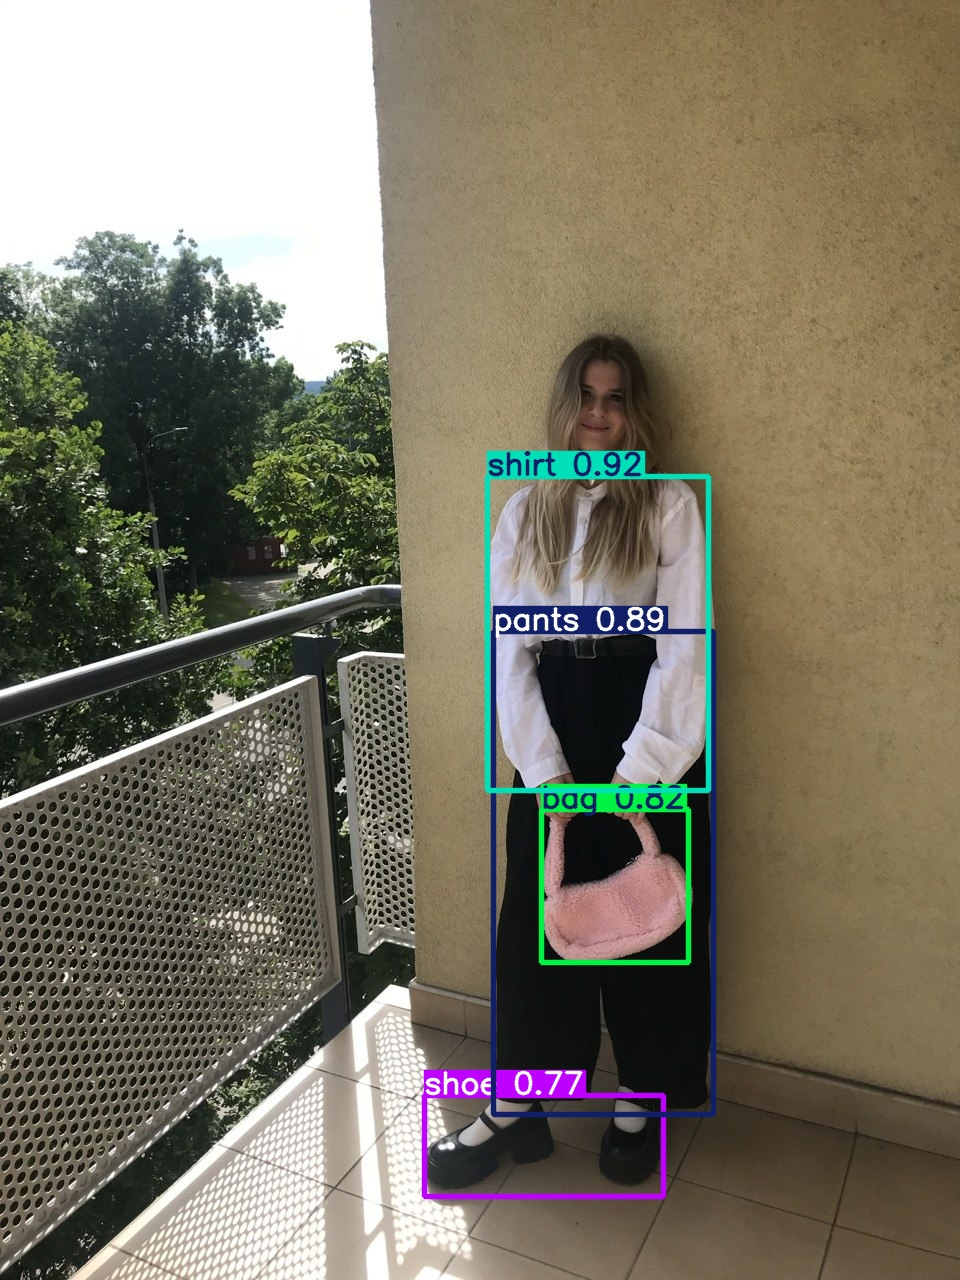


Model: YOLOv8


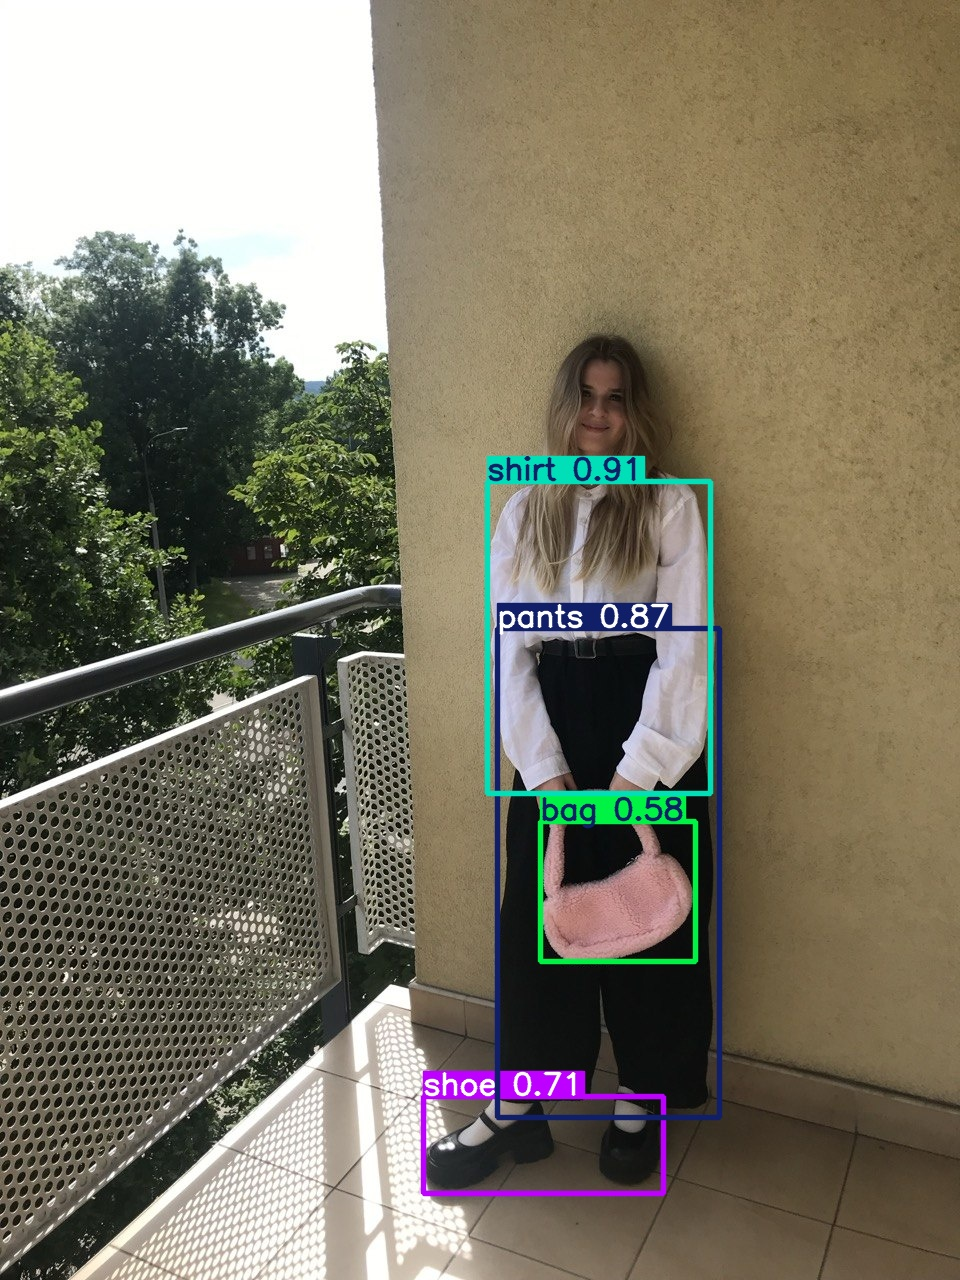


Model: YOLO11


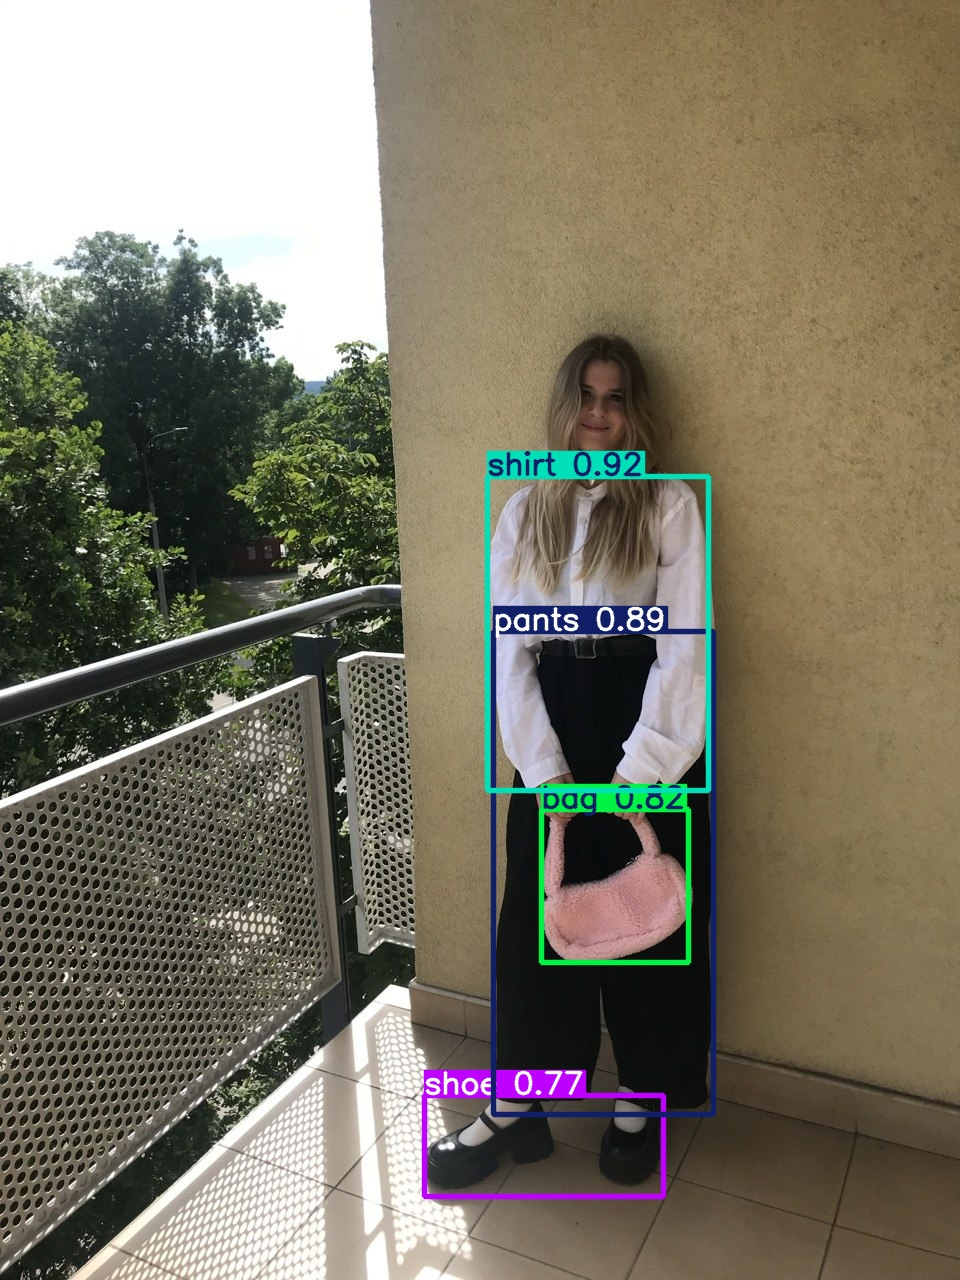

In [21]:
from IPython.display import Image, display
import os

# Lista nazw folderów, które utworzyły się podczas predykcji
model_folders = ["YOLOv5", "YOLOv8", "YOLO11"]

print("--- Wyniki detekcji dla poszczególnych modeli ---")

for folder in model_folders:
    # Ścieżka do zapisanego pliku - zazwyczaj nazwa pliku wejściowego jest zachowana
    # Upewnij się, że 'test.jpg' to faktycznie nazwa pliku wejściowego
    img_path = os.path.join("runs/detect/Wyniki_Testow", folder, "test.jpg")

    if os.path.exists(img_path):
        print(f"\nModel: {folder}")
        display(Image(filename=img_path))
    else:
        print(f"\nNie znaleziono pliku dla modelu {folder} pod ścieżką: {img_path}")